<a href="https://colab.research.google.com/github/kaxmarc/statistics_ml/blob/main/group_exercises/exercise_3/Group_Exercise_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chapter 2 – Group Exercise 3: Neural Networks**

**Group Exercise 3**

Group consisting of Ritu, Vikrant Singh and Kay Müller

Dataset "House Prices - Advanced Regression Techniques"

The dataset contains properties with various environmental variables.

Source:

https://www.kaggle.com/datasets/rishitaverma02/house-prices-advanced-regression-techniques

You may select one of the following models:

Feedforward Neural Network (FNN / MLP); Recurrent Neural Network (RNN); Long Short-Term Memory (LSTM); Convolutional Neural Network (CNN)

**Our choice:**

Feedforward Neural Network (FNN / MLP) is best suited for our house dataset.
Reasons:
1. Features (area, location, year, etc.) have a non-sequential relationship to price: input > hidden > output.
2. Each feature stands alone without spatial dependencies, which protects it from overfitting due to its simplicity.
3. It uses basic classification (structured numerical data), which makes it suitable for regression.

**Why not the others?**

*Recurrent Neural Network (RNN)* is designed for time series, text and speech. It requires a temporal or sequential order in the input. The house features do not have this (e.g. area -> location -> units is not bound to order).

*Long Short-Term Memory (LSTM)* is optimised for long sequences in temporal dependencies (includes gates for controlling what is retained and forgotten). This method would make sense if we were to create time series of house prices (over months and years) using suitable input, which we do not have.

*Convolutional neural networks (CNNs)* are optimised for spatial patterns, especially in images (recognising edges, shapes and textures). This would make sense if we were examining images such as floor plans, site plans and satellite images, which would require a different input.

**In summary:**
FNN is suitable for our classic simple dataset in tabular form and structure. Due to its characteristics, it is on a par with Random Forest and Gradient Boosting, which would also be suitable.



In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

# 1. Dataset and Preprocessing

In [51]:
df = pd.read_csv('https://raw.githubusercontent.com/kaxmarc/statistics_ml/refs/heads/main/datasets/train_house.csv') # RAW Data from GitHub
print("Shape:", df.shape)
#df.head()

Shape: (1460, 81)


In [52]:
missing_values = df.isnull().sum().sort_values(ascending=False)
if missing_values.sum() > 0:
  print(f"\n{'='*55}\nImportant: Edit missing values!\n{'='*55}")
  print(df.isnull().sum().sort_values(ascending=False))


Important: Edit missing values!
PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64


In [53]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns
# numerical imputation
imput_median = SimpleImputer(strategy="median")
imput_mean = SimpleImputer(strategy="mean")

for feature in numerical_columns:

  if df[feature].isnull().sum().mean() == 0:
    continue

  print(f"Numerical Feature {feature} missing: {df[feature].isnull().sum()}")
  if df[feature].skew() > 1 or df[feature].skew() < -1:
    # imput_median
    df[[feature]] = imput_median.fit_transform(df[[feature]])
    print(f"Numerical Feature {feature} imputed {imput_median.strategy}")
  else:
    # imput_mean
    df[[feature]] = imput_mean.fit_transform(df[[feature]])
    print(f"Numerical Feature {feature} imputed {imput_mean.strategy}")


# categorical imputation
imputer_mode = SimpleImputer(strategy="most_frequent")

for feature in categorical_columns:
  if df[feature].isnull().sum() == 0:
    continue

  print(f"Categorical Feature {feature} missing: {df[feature].isnull().sum()}")
  df[[feature]] = imputer_mode.fit_transform(df[[feature]])
  print(f"Categorical Feature {feature} imputed {imputer_mode.strategy}")


# Adjusted features
print("\nAdjusted features:")
print(df.isnull().sum().sort_values(ascending=False))
#df.head()

Numerical Feature LotFrontage missing: 259
Numerical Feature LotFrontage imputed median
Numerical Feature MasVnrArea missing: 8
Numerical Feature MasVnrArea imputed median
Numerical Feature GarageYrBlt missing: 81
Numerical Feature GarageYrBlt imputed mean
Categorical Feature Alley missing: 1369
Categorical Feature Alley imputed most_frequent
Categorical Feature MasVnrType missing: 872
Categorical Feature MasVnrType imputed most_frequent
Categorical Feature BsmtQual missing: 37
Categorical Feature BsmtQual imputed most_frequent
Categorical Feature BsmtCond missing: 37
Categorical Feature BsmtCond imputed most_frequent
Categorical Feature BsmtExposure missing: 38
Categorical Feature BsmtExposure imputed most_frequent
Categorical Feature BsmtFinType1 missing: 37
Categorical Feature BsmtFinType1 imputed most_frequent
Categorical Feature BsmtFinType2 missing: 38
Categorical Feature BsmtFinType2 imputed most_frequent
Categorical Feature Electrical missing: 1
Categorical Feature Electrical i

In [54]:
# Irrelevant features
df = df.drop('Id', axis=1)

# OneHot-Encoding
categorical_columns = df.select_dtypes(include="object").columns.tolist()
df = pd.get_dummies(df, columns=categorical_columns, drop_first=False)

print(f"Shape nach Encoding: {df.shape}")
print(f"Dtypes:\n{df.dtypes.value_counts()}")

# Separate features and target variable
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']


Shape nach Encoding: (1460, 288)
Dtypes:
bool       251
int64       34
float64      3
Name: count, dtype: int64


In [55]:
#df.head()


# Problem Type: Regression task
The target variable (SalePrice) is a numerical value and can take on any value. **This is a regression problem.**
In contrast, a classification task requires a target variable with a categorical label that is also finite. Converting SalePrice into, for example, "low" and "high" would classify the information.

## Version 1: Feedforward Neural Network (MLP) - STANDARD

In [56]:
results = {} # for final version comparison

In [57]:
# Train/Test Split (80%/20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# for comparison
y_train_log = np.log(y_train).values.reshape(-1, 1)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_log).ravel()


print(f"Training:   {X_train_scaled.shape[0]} Samples")
print(f"Test:       {X_test_scaled.shape[0]} Samples")

Training:   1168 Samples
Test:       292 Samples


In [58]:
mlp = MLPRegressor(
  hidden_layer_sizes=(64, 32),
  activation='relu',
  max_iter=1000,
  random_state=42,
  early_stopping=True,
  validation_fraction=0.1
)

mlp.fit(X_train_scaled, y_train)

print(f"Number of iterations:   {mlp.n_iter_}")
print(f"Final Loss:             {mlp.loss_:.2f}")

Number of iterations:   732
Final Loss:             326790267.99


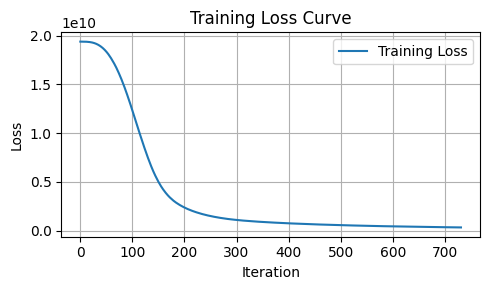

In [59]:
# Loss Curve
plt.figure(figsize=(5, 3))
plt.plot(mlp.loss_curve_, label='Training Loss')
plt.title('Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Interpretation:

In the 100 iterations, the loss or error rate is still very high. In the following 200 iterations, the network learns the essential relationships, including characteristics and conditions in relation to price. As a result, the network tends towards 0, which indicates good convergence.

In [60]:
y_pred = mlp.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

results["MLP Standard"] = rmse
print(f"RMSE:                 {rmse:,.2f}")
print(f"Average sale price:   {y_test.mean():,.2f}")
print(f"RMSE as % of average: {rmse / y_test.mean() * 100:.1f}%")

RMSE:                 39,885.17
Average sale price:   178,839.81
RMSE as % of average: 22.3%


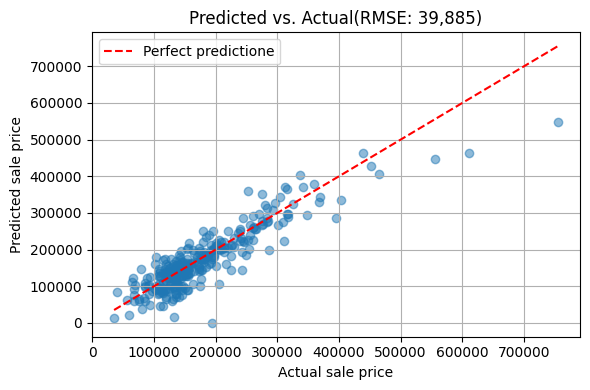

In [61]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect predictione')
plt.xlabel('Actual sale price')
plt.ylabel('Predicted sale price')
plt.title(f'Predicted vs. Actual(RMSE: {rmse:,.0f})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Interpretation:

In the low to medium price segment, the dispersion is very low and the prediction is very reliable. However, from 350,000 upwards, the dispersion increases significantly. The model underestimates expensive houses. In this context, we suspect the "more expensive" outliers, which are supported by less information. Otherwise, the dataset is very stable, with only a few outliers (including towards 0), which may well be due to feature deviations.

## Version 2: Feedforward Neural Network (MLP) - TUNED

In [62]:
# Hyperparameter-Tuning
param_grid = {
  "hidden_layer_sizes": [(64, 32), (128, 64), (128, 64, 32)],
  "learning_rate_init": [0.01, 0.001, 0.0001],
}

grid = GridSearchCV(
  MLPRegressor(max_iter=1000, early_stopping=True, random_state=42),
  param_grid,
  cv=5,
  scoring="neg_mean_squared_error",
  n_jobs=-1
)
grid.fit(X_train_scaled, y_train_scaled)

print(f"Best parameters:      {grid.best_params_}") # return aus GridSearchCV

# Forecast with best model
y_pred_scaled = grid.best_estimator_.predict(X_test_scaled).reshape(-1, 1)
y_pred_log = y_scaler.inverse_transform(y_pred_scaled).ravel() # inverse transformation
y_pred = np.exp(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
avg_price = y_test.mean()
results["MLP Tuned"] = rmse
print(f"RMSE:                 {rmse:,.2f}")
print(f"Average sale price:   {y_test.mean():,.2f}")
print(f"RMSE as % of average: {rmse / y_test.mean() * 100:.1f}%")



Best parameters:      {'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.01}
RMSE:                 29,258.41
Average sale price:   178,839.81
RMSE as % of average: 16.4%


In [63]:
print("\nStandard MLP vs. Tuned MLP")
print("="*55, "\n")
for name, rmse in results.items():
    print(f"  {name}: {rmse:,.2f} ({rmse/avg_price*100:.1f}%)\n")


Standard MLP vs. Tuned MLP

  MLP Standard: 39,885.17 (22.3%)

  MLP Tuned: 29,258.41 (16.4%)



Conclusion:

Comparisons of the two versions show a 6% improvement, which was achieved through tuning measures. The deepest network we specified (128, 64, 32) performed best in combination with a higher learning rate.
At 16.4%, the model delivers an acceptable deviation, taking into account the existing but nevertheless relevant outliers.